# Comparison of mapping methods

In this notebook, we show how to use AprilTags to map from gaze-to screen coordinates. Along the way, we will also show some additional epoching functionalities.

To do so, we have collected a dataset where a participant freely views artworks presented on screen. Each artwork is shown for 4s, followed by a 0.5s inter trial intervall and a 0.5s central fixation cross. We can download this dataset using `get_sample_data()`.

In [1]:
import numpy as np
from pyneon import Recording, get_sample_data

# Load a sample recording
rec_dir = (
    get_sample_data("Artworks") / "Timeseries Data + Scene Video" / "artworks-9a141750"
)
print("Loading sample recording from:", rec_dir)
rec = Recording(rec_dir)
print(rec)

Loading sample recording from: C:\Users\jan-gabriel.hartel\Documents\GitHub\PyNeon\data\Artworks\Timeseries Data + Scene Video\artworks-9a141750

Recording ID: 9a141750-95ca-48ee-9693-53bbb896b87e
Wearer ID: c4f68887-e96c-467f-a901-0fc9fce09c0a
Wearer name: JGH
Recording start time: 2025-06-16 12:49:27.817000
Recording duration: 357.538s
                 exist                  filename                                                                                                                                        path
3d_eye_states     True         3d_eye_states.csv         C:\Users\jan-gabriel.hartel\Documents\GitHub\PyNeon\data\Artworks\Timeseries Data + Scene Video\artworks-9a141750\3d_eye_states.csv
blinks            True                blinks.csv                C:\Users\jan-gabriel.hartel\Documents\GitHub\PyNeon\data\Artworks\Timeseries Data + Scene Video\artworks-9a141750\blinks.csv
events            True                events.csv                C:\Users\jan-gabriel.hartel\D

Let us take a closer look at the events file, populated with triggers sent during the initial viewing

In [2]:
event_data = rec.events.data
print(event_data.head(10))

                                                                  name  \
timestamp [ns]                                                           
1750070967817000000                                    recording.begin   
1750070973028401000                                     fixation onset   
1750070973726906000   image onset 8c63372e-dfd6-ab25-cfc8-a6569f25f0c8   
1750070977877138000  image offset 8c63372e-dfd6-ab25-cfc8-a6569f25f0c8   
1750070978659847000                                     fixation onset   
1750070979391162000   image onset 29a102da-4838-432b-7373-a3c7f5679d75   
1750070983510925000  image offset 29a102da-4838-432b-7373-a3c7f5679d75   
1750070984367660000                                     fixation onset   
1750070985019038000   image onset 9c15b0f6-c5d3-ffa3-a853-0a62a4520400   
1750070989241548000  image offset 9c15b0f6-c5d3-ffa3-a853-0a62a4520400   

                          type  
timestamp [ns]                  
1750070967817000000  recording  
175007097302

We can see that the name column holds the information ofinterest to us. As the column ontains both information about the event_type as well as its name, we will first parse these apart. This process is a bit lengthy, but necessary to make sense of our data

In [3]:
# parse the name column, look for the key words image onset and image offset
def parse_event_name(name):
    if "image onset" in name.lower():
        type = "image onset"
        name = name.lower().replace("image onset ", "").strip()
    elif "image offset" in name.lower():
        type = "image offset"
        name = name.lower().replace("image offset ", "").strip()
    else:
        type = "other"
        name = None
    return type, name


for i, row in event_data.iterrows():
    type, name = parse_event_name(row["name"])
    event_data.at[i, "event_type"] = type
    event_data.at[i, "image_name"] = name

print(event_data.head(5))

                                                                  name  \
timestamp [ns]                                                           
1750070967817000000                                    recording.begin   
1750070973028401000                                     fixation onset   
1750070973726906000   image onset 8c63372e-dfd6-ab25-cfc8-a6569f25f0c8   
1750070977877138000  image offset 8c63372e-dfd6-ab25-cfc8-a6569f25f0c8   
1750070978659847000                                     fixation onset   

                          type    event_type  \
timestamp [ns]                                 
1750070967817000000  recording         other   
1750070973028401000  recording         other   
1750070973726906000  recording   image onset   
1750070977877138000  recording  image offset   
1750070978659847000  recording         other   

                                               image_name  
timestamp [ns]                                             
1750070967817000000     

Resetting video...
Resetting video...
Resetting video...


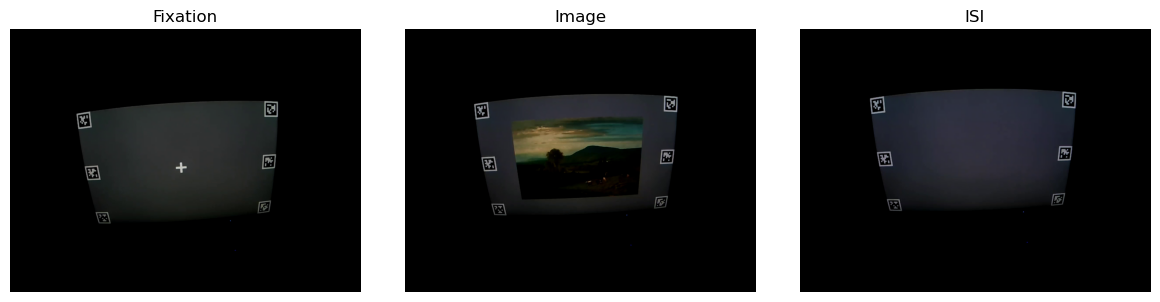

In [4]:
import matplotlib.pyplot as plt

video = rec.video

fig, axs = plt.subplots(1, 3, figsize=(12, 3))
video.plot_frame(170, ax=axs[0], auto_title=False, show=False)
video.plot_frame(200, ax=axs[1], auto_title=False, show=False)
video.plot_frame(320, ax=axs[2], auto_title=False, show=False)
axs[0].set_title("Fixation")
axs[1].set_title("Image")
axs[2].set_title("ISI")
plt.tight_layout()
plt.show()

In all of the frames shown above, we can see QR-code like markers at the borders of the screen. These are called apriltags and can be used as fiducial markers to relate video to real-world coordinates. PyNeon wraps a function that performs the detection of these. For computational efficiency, we only perform one detection every 30 frames.

In [ ]:
screen_detections = rec.detect_screen_corners(skip_frames=10, overwrite=True)
screen_detections_data = screen_detections.data
print(screen_detections.data.head())

april_detections = rec.detect_apriltags(
    skip_frames=10, return_diagnostics=True, overwrite=True
)
april_detections_data = april_detections.data
print(april_detections.data.head())

Loading saved detections from C:\Users\jan-gabriel.hartel\Documents\GitHub\PyNeon\data\Artworks\Timeseries Data + Scene Video\artworks-9a141750\derivatives\screen.json
                     processed_frame_idx  frame_idx  tag_id  \
timestamp [ns]                                                
1750070971664700000                    0         90       0   
1750070972664322222                    1        120       0   
1750070973663944444                    2        150       0   
1750070974663577777                    3        180       0   
1750070975663200000                    4        210       0   

                                                               corners  \
timestamp [ns]                                                           
1750070971664700000  [[262.0, 413.0], [1191.0, 348.0], [1159.0, 843...   
1750070972664322222  [[409.0, 486.0], [1324.0, 347.0], [1328.0, 847...   
1750070973663944444  [[444.0, 358.0], [1366.0, 427.0], [1257.0, 924...   
1750070974663577777 

C:\Users\jan-gabriel.hartel\Documents\GitHub\PyNeon\pyneon\tabular.py:61: UserWarning: Column 'method' not in data_types, using default data type.
  warn(f"Column '{col}' not in data_types, using default data type.")
C:\Users\jan-gabriel.hartel\Documents\GitHub\PyNeon\pyneon\tabular.py:61: UserWarning: Column 'area_ratio' not in data_types, using default data type.
  warn(f"Column '{col}' not in data_types, using default data type.")
C:\Users\jan-gabriel.hartel\Documents\GitHub\PyNeon\pyneon\tabular.py:61: UserWarning: Column 'score' not in data_types, using default data type.
  warn(f"Column '{col}' not in data_types, using default data type.")
C:\Users\jan-gabriel.hartel\Documents\GitHub\PyNeon\pyneon\tabular.py:61: UserWarning: Column 'hamming' not in data_types, using default data type.
  warn(f"Column '{col}' not in data_types, using default data type.")
C:\Users\jan-gabriel.hartel\Documents\GitHub\PyNeon\pyneon\tabular.py:61: UserWarning: Column 'decision_margin' not in data_type

Having detected the apriltags, we now need to provide information on the real-world coordinates of our apriltags. This is solved via a tag_info dataframe, which we generate below.

In [6]:
import pandas as pd


def generate_tag_info(win_size, tag_ids=None, tag_size=200):
    """
    Generate marker information for a given window size.

    Args:
        win_size (tuple): The width and height of the window.
        tag_ids (list, optional): List of tag IDs. Defaults to [0, 1, 2, 3, 4, 5].
        tag_size (int, optional): Size of the tags. Defaults to 200.

    Returns:
        pd.DataFrame: A DataFrame containing marker IDs and their corner positions.
    """
    if tag_ids is None:
        tag_ids = [0, 1, 2, 3, 4, 5]  # Default tag IDs

    win_half_width, win_half_height = np.array(win_size) / 2
    half_tag_size = tag_size / 2

    positions = [
        (-win_half_width + half_tag_size, win_half_height - half_tag_size),  # top-left
        (-win_half_width + half_tag_size, 0),  # middle-left
        (
            -win_half_width + half_tag_size,
            -win_half_height + half_tag_size,
        ),  # bottom-left
        (win_half_width - half_tag_size, win_half_height - half_tag_size),  # top-right
        (win_half_width - half_tag_size, 0),  # middle-right
        (
            win_half_width - half_tag_size,
            -win_half_height + half_tag_size,
        ),  # bottom-right
    ]

    marker_corners = []
    for pos in positions:
        cx, cy = pos
        corners = [
            [cx - half_tag_size, cy + half_tag_size],  # top-left
            [cx + half_tag_size, cy + half_tag_size],  # top-right
            [cx + half_tag_size, cy - half_tag_size],  # bottom-right
            [cx - half_tag_size, cy - half_tag_size],  # bottom-left
        ]
        marker_corners.append(corners)

    tag_info = pd.DataFrame({"marker_id": tag_ids, "marker_corners": marker_corners})

    return tag_info


tag_info = generate_tag_info((1920, 1080))

In [7]:
print(tag_info)

   marker_id                                     marker_corners
0          0  [[-960.0, 540.0], [-760.0, 540.0], [-760.0, 34...
1          1  [[-960.0, 100.0], [-760.0, 100.0], [-760.0, -1...
2          2  [[-960.0, -340.0], [-760.0, -340.0], [-760.0, ...
3          3  [[760.0, 540.0], [960.0, 540.0], [960.0, 340.0...
4          4  [[760.0, 100.0], [960.0, 100.0], [960.0, -100....
5          5  [[760.0, -340.0], [960.0, -340.0], [960.0, -54...


With this, we can now run the ``find_homograpghy()`` method. This method finds the map between the detections and the provided coordinates for each frame. As we did not do detections in every frame, we further provide the skip_frames as used before so that the homographies can be interpolated.

In [ ]:
screen_homographies = rec.find_homographies(
    tag_info=None,
    all_detections=screen_detections,
    surface_size=(1920, 1080),
    skip_frames=10,
    sample_ts=rec.gaze.ts,
    overwrite=True,
)

april_homographies = rec.find_homographies(
    tag_info=tag_info,
    all_detections=april_detections,
    skip_frames=10,
    sample_ts=rec.gaze.ts,
    coordinate_system="psychopy",
    overwrite=True,
)

Computing homographies for frames: 100%|██████████| 353/353 [00:01<00:00, 271.37it/s]


In [9]:
gaze_with_screen = rec.gaze_on_surface(
    tag_info=None, homographies=screen_homographies, sample_to="gaze", overwrite=True
)

gaze_with_april = rec.gaze_on_surface(
    tag_info=tag_info, homographies=april_homographies, sample_to="gaze", overwrite=True
)

In [10]:
print(gaze_with_screen.data.head())
print(gaze_with_april.data.head())

                     gaze x [px]  gaze y [px]  worn  fixation id  blink id  \
timestamp [ns]                                                               
1750070970217815359      685.360      585.650     1            1      <NA>   
1750070970222935359      686.354      584.295     1            1      <NA>   
1750070970227935359      689.801      583.098     1            1      <NA>   
1750070970232948359      687.214      594.618     1            1      <NA>   
1750070970237935359      687.090      595.185     1            1      <NA>   

                     azimuth [deg]  elevation [deg]     x_trans     y_trans  
timestamp [ns]                                                               
1750070970217815359      -7.207620         1.740405  823.414836  391.913461  
1750070970222935359      -7.143791         1.827646  825.566284  389.626056  
1750070970227935359      -6.921942         1.904967  832.405981  388.005407  
1750070970232948359      -7.087129         1.163872  825.391006

Text(0.5, 0, 'Time (s)')

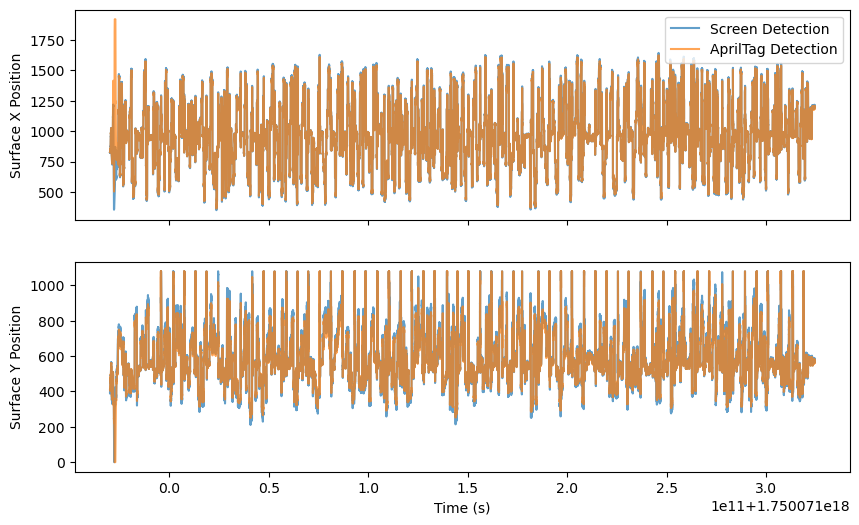

In [11]:
# plot comparison
screen_data = gaze_with_screen.data
april_data = gaze_with_april.data

# clip x and y to surface size
surface_width, surface_height = 1920, 1080
screen_data["x_trans"] = screen_data["x_trans"].clip(0, surface_width)
screen_data["y_trans"] = screen_data["y_trans"].clip(0, surface_height)
april_data["x_trans"] = april_data["x_trans"].clip(0, surface_width)
april_data["y_trans"] = april_data["y_trans"].clip(0, surface_height)

# plot x and y trajectories over time
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(
    screen_data.index, screen_data["x_trans"], label="Screen Detection", alpha=0.7
)
axs[0].plot(
    april_data.index, april_data["x_trans"], label="AprilTag Detection", alpha=0.7
)
axs[0].set_ylabel("Surface X Position")
axs[0].legend()
axs[1].plot(
    screen_data.index, screen_data["y_trans"], label="Screen Detection", alpha=0.7
)
axs[1].plot(
    april_data.index, april_data["y_trans"], label="AprilTag Detection", alpha=0.7
)
axs[1].set_ylabel("Surface Y Position")
axs[1].set_xlabel("Time (s)")

In [12]:
# calcualet correlation coefficients
screen_valid = screen_data.dropna(subset=["x_trans", "y_trans"])
april_valid = april_data.dropna(subset=["x_trans", "y_trans"])

common_index = screen_valid.index.intersection(april_valid.index)
corr_x = screen_valid.loc[common_index, "x_trans"].corr(
    april_valid.loc[common_index, "x_trans"]
)
corr_y = screen_valid.loc[common_index, "y_trans"].corr(
    april_valid.loc[common_index, "y_trans"]
)

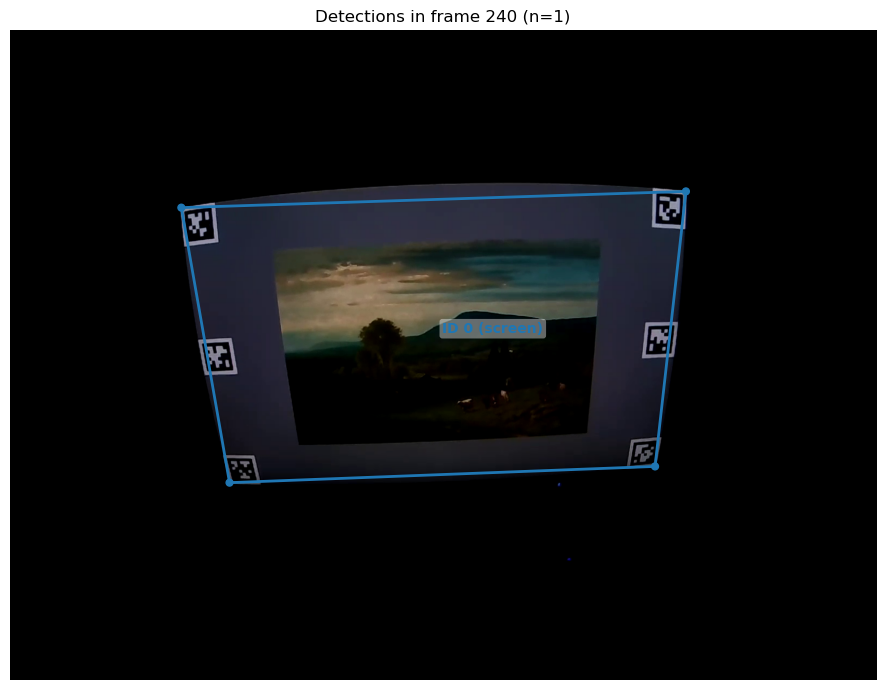

In [13]:
from pyneon.vis.mapping import plot_frame_detections

plot_frame_detections(
    video,
    screen_detections_data,
    frame_index=240,
)

In [ ]:
from pyneon.vis.mapping import detection_overlay_video

detection_overlay_video(
    video,
    screen_detections_data,
    out_path=rec.der_dir / "screen_detections_overlay.mp4",
    max_miss=10,
)

Creating detection overlay video: 100%|██████████| 10695/10695 [02:52<00:00, 62.03it/s]


WindowsPath('C:/Users/jan-gabriel.hartel/Documents/GitHub/PyNeon/data/Artworks/Timeseries Data + Scene Video/artworks-9a141750/derivatives/screen_detections_overlay.mp4')

In [ ]:
detection_overlay_video(
    video,
    april_detections_data,
    out_path=rec.der_dir / "april_detections_overlay.mp4",
    max_miss=10,
)

Creating detection overlay video: 100%|██████████| 10695/10695 [03:27<00:00, 51.65it/s]


WindowsPath('C:/Users/jan-gabriel.hartel/Documents/GitHub/PyNeon/data/Artworks/Timeseries Data + Scene Video/artworks-9a141750/derivatives/april_detections_overlay.mp4')